# **Case Study: Diabetes Disease Progression Prediction**

**imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


**Load the Diabetes dataset**

In [2]:
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

df = X.copy()
df["target"] = y

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


**Understand the features**

In [3]:
print("Features:")
for feature in diabetes.feature_names:
    print("-", feature)

print("\nTarget:")
print("Disease progression measure")

Features:
- age
- sex
- bmi
- bp
- s1
- s2
- s3
- s4
- s5
- s6

Target:
Disease progression measure


**Basic dataset analysis**

In [4]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Shape: (442, 11)

Data Types:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

Missing Values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


**Basic EDA**

**Target distribution**

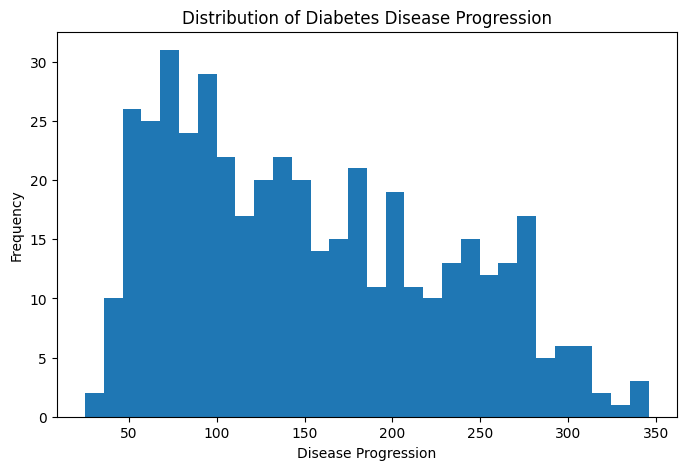

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")
plt.title("Distribution of Diabetes Disease Progression")
plt.show()

**BMI vs target**

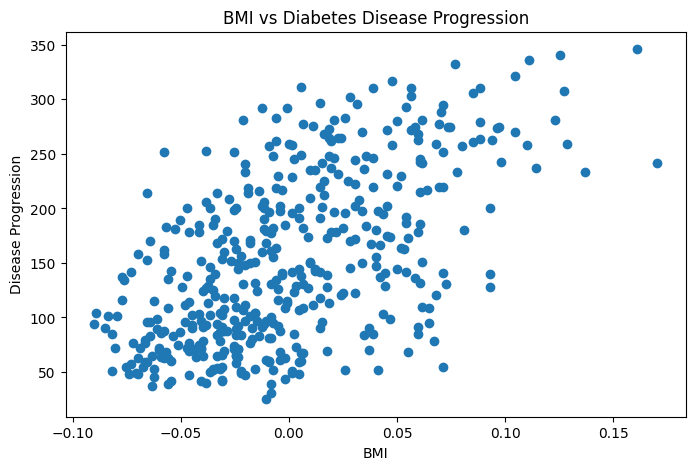

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df["bmi"], df["target"])
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("BMI vs Diabetes Disease Progression")
plt.show()

**Correlation matrix**

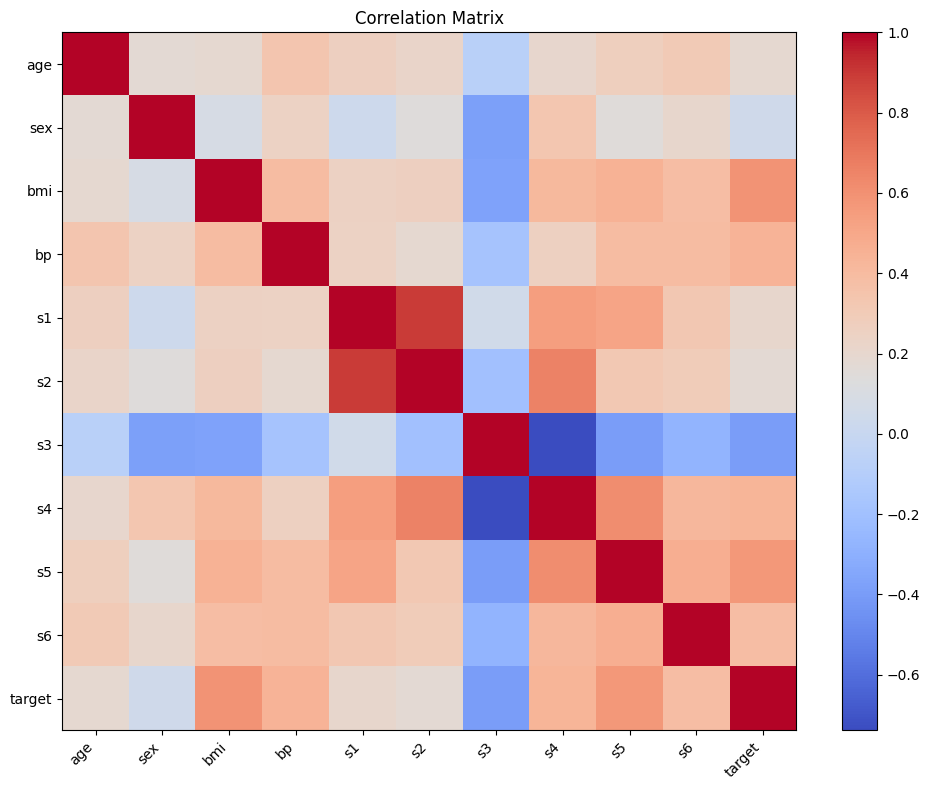

In [7]:
plt.figure(figsize=(10, 8))
plt.imshow(df.corr(), cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(df.columns)),
    df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(df.columns)),
    df.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Data Preprocessing and Train/Test Split**

In [8]:
# Separate input and target
X = diabetes.data
y = diabetes.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


**Simple Linear Regression**

In [9]:
# Select BMI as the single predictor
X_bmi = X[["bmi"]]

# Train-test split for Simple Linear Regression
X_train_bmi, X_test_bmi, y_train_bmi, y_test_bmi = train_test_split(
    X_bmi,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train_bmi.shape[0])
print("Testing samples:", X_test_bmi.shape[0])

Training samples: 353
Testing samples: 89


**Train the Simple Linear Regression model**

In [10]:
from sklearn.linear_model import LinearRegression

# Create model
simple_lr = LinearRegression()

# Train model
simple_lr.fit(X_train_bmi, y_train_bmi)

# Make predictions
y_pred_simple = simple_lr.predict(X_test_bmi)

print("Intercept:", simple_lr.intercept_)
print("BMI coefficient:", simple_lr.coef_[0])

Intercept: 152.00335421448167
BMI coefficient: 998.5776891375598


**Evaluate the model**

In [11]:
# Calculate evaluation metrics
mse_simple = mean_squared_error(y_test_bmi, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple = mean_absolute_error(y_test_bmi, y_pred_simple)
r2_simple = r2_score(y_test_bmi, y_pred_simple)

print("Simple Linear Regression Performance")
print("--------------------------------------")
print("MSE  :", mse_simple)
print("RMSE :", rmse_simple)
print("MAE  :", mae_simple)
print("R²   :", r2_simple)

Simple Linear Regression Performance
--------------------------------------
MSE  : 4061.8259284949268
RMSE : 63.73245584860925
MAE  : 52.259976445345536
R²   : 0.23335039815872138


**Create an Actual vs Predicted graph**

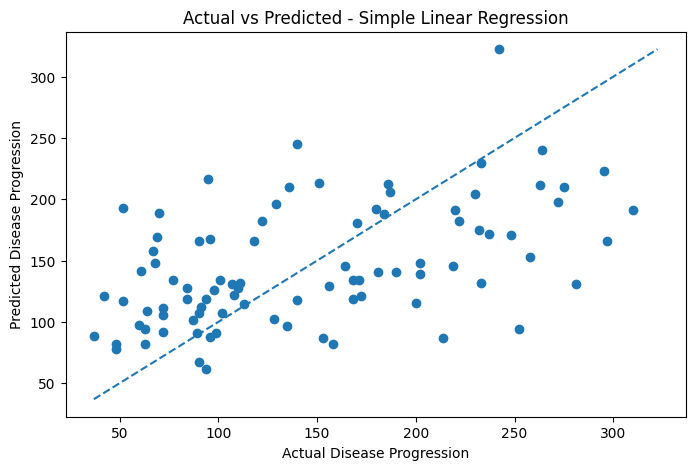

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test_bmi, y_pred_simple)

# Perfect prediction line
min_value = min(y_test_bmi.min(), y_pred_simple.min())
max_value = max(y_test_bmi.max(), y_pred_simple.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Actual vs Predicted - Simple Linear Regression")
plt.show()

**Plot the regression line**

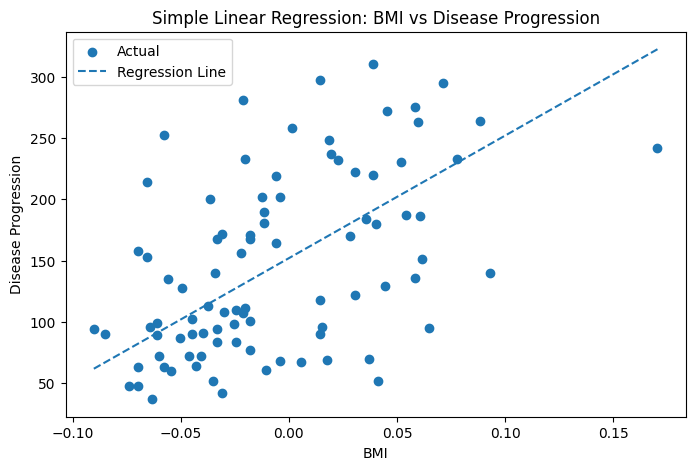

In [13]:
# Sort values so the line is displayed correctly
sorted_indices = np.argsort(X_test_bmi["bmi"].values)

X_sorted = X_test_bmi["bmi"].values[sorted_indices]
y_sorted_pred = y_pred_simple[sorted_indices]

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_bmi["bmi"],
    y_test_bmi,
    label="Actual"
)

plt.plot(
    X_sorted,
    y_sorted_pred,
    linestyle="--",
    label="Regression Line"
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.legend()
plt.show()

**First results table**

In [14]:
simple_result = pd.DataFrame({
    "Model": ["Simple Linear Regression"],
    "MSE": [mse_simple],
    "RMSE": [rmse_simple],
    "MAE": [mae_simple],
    "R2": [r2_simple]
})

simple_result

,Model,MSE,RMSE,MAE,R2
0,Simple Linear Regression,4061.825928,63.732456,52.259976,0.23335


**Multiple Linear Regression**

**Prepare the data**

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (353, 10)
X_test shape : (89, 10)
y_train shape: (353,)
y_test shape : (89,)


**Train Multiple Linear Regression**

In [16]:
# Create Multiple Linear Regression model
multiple_lr = LinearRegression()

# Train the model
multiple_lr.fit(X_train, y_train)

# Predict on test data
y_pred_multiple = multiple_lr.predict(X_test)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


**View model coefficients**

In [17]:
coefficients = pd.DataFrame({
    "Feature": diabetes.feature_names,
    "Coefficient": multiple_lr.coef_
})

coefficients

,Feature,Coefficient
0,age,37.904021
1,sex,-241.964362
2,bmi,542.428759
3,bp,347.703844
4,s1,-931.488846
5,s2,518.062277
6,s3,163.419983
7,s4,275.317902
8,s5,736.198859
9,s6,48.670657


In [18]:
coefficients["Absolute Coefficient"] = np.abs(
    coefficients["Coefficient"]
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


In [19]:
print("Intercept:", multiple_lr.intercept_)

Intercept: 151.34560453985995


**Evaluate the model**

In [20]:
mse_multiple = mean_squared_error(
    y_test,
    y_pred_multiple
)

rmse_multiple = np.sqrt(mse_multiple)

mae_multiple = mean_absolute_error(
    y_test,
    y_pred_multiple
)

r2_multiple = r2_score(
    y_test,
    y_pred_multiple
)

print("Multiple Linear Regression Performance")
print("---------------------------------------")
print("MSE  :", mse_multiple)
print("RMSE :", rmse_multiple)
print("MAE  :", mae_multiple)
print("R²   :", r2_multiple)

Multiple Linear Regression Performance
---------------------------------------
MSE  : 2900.1936284934814
RMSE : 53.85344583676593
MAE  : 42.79409467959994
R²   : 0.4526027629719195


**Actual vs Predicted graph**

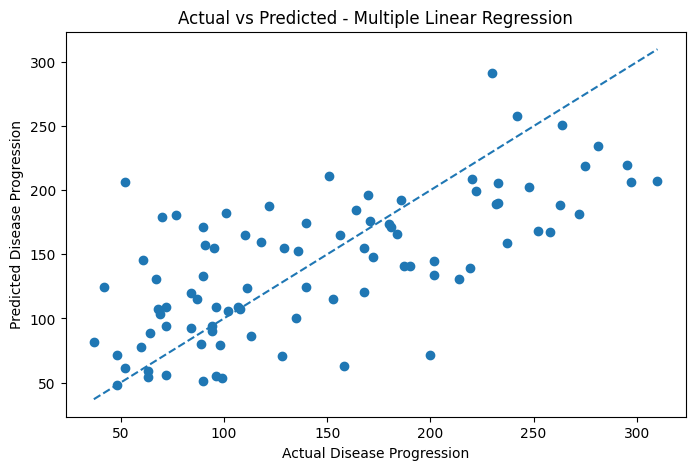

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_multiple)

min_value = min(
    y_test.min(),
    y_pred_multiple.min()
)

max_value = max(
    y_test.max(),
    y_pred_multiple.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Actual vs Predicted - Multiple Linear Regression")

plt.show()

**Compare Simple vs Multiple Linear Regression**

In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MSE": [
        mse_simple,
        mse_multiple
    ],
    "RMSE": [
        rmse_simple,
        rmse_multiple
    ],
    "MAE": [
        mae_simple,
        mae_multiple
    ],
    "R2": [
        r2_simple,
        r2_multiple
    ]
})

comparison

,Model,MSE,RMSE,MAE,R2
0,Simple Linear Regression,4061.825928,63.732456,52.259976,0.233350
1,Multiple Linear Regression,2900.193628,53.853446,42.794095,0.452603


**Calculate the improvement**

In [23]:
r2_change = r2_multiple - r2_simple

rmse_change = rmse_simple - rmse_multiple

print("Change in R²  :", r2_change)
print("Reduction in RMSE:", rmse_change)

Change in R²  : 0.2192523648131981
Reduction in RMSE: 9.87901001184332


**metric comparison chart**

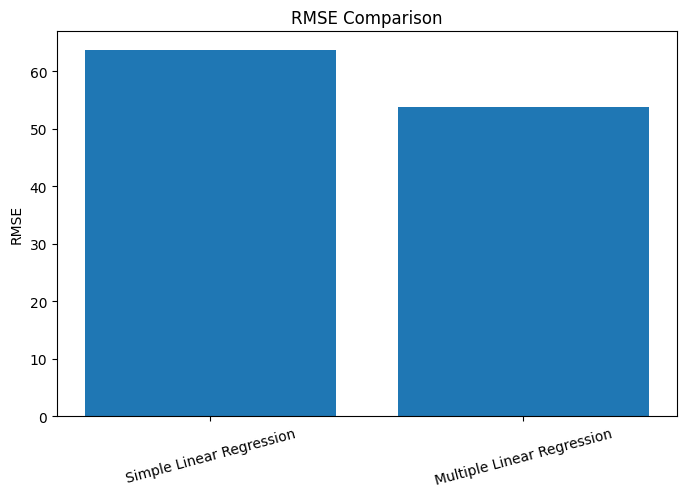

In [24]:
models = comparison["Model"]
rmse_values = comparison["RMSE"]

plt.figure(figsize=(8, 5))

plt.bar(models, rmse_values)

plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.xticks(rotation=15)

plt.show()

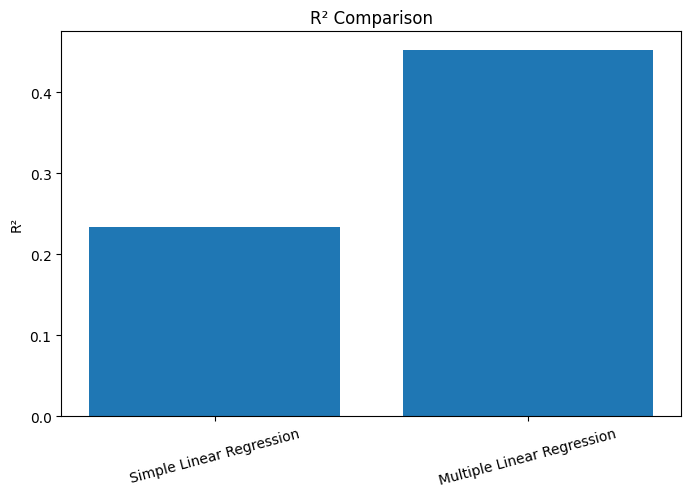

In [25]:
r2_values = comparison["R2"]

plt.figure(figsize=(8, 5))

plt.bar(models, r2_values)

plt.ylabel("R²")
plt.title("R² Comparison")

plt.xticks(rotation=15)

plt.show()

**Polynomial Regression**

**Degree 2 Polynomial Regression**

In [26]:
from sklearn.preprocessing import PolynomialFeatures

poly2 = PolynomialFeatures(degree=2)

X_train_poly2 = poly2.fit_transform(X_train_bmi)
X_test_poly2 = poly2.transform(X_test_bmi)

print("Original features:", X_train_bmi.shape[1])
print("Polynomial features:", X_train_poly2.shape[1])

Original features: 1
Polynomial features: 3


**Train Degree 2 model**

In [27]:
poly2_model = LinearRegression()

poly2_model.fit(
    X_train_poly2,
    y_train_bmi
)

y_pred_poly2 = poly2_model.predict(X_test_poly2)

**Evaluate Degree 2**

In [28]:
mse_poly2 = mean_squared_error(
    y_test_bmi,
    y_pred_poly2
)

rmse_poly2 = np.sqrt(mse_poly2)

mae_poly2 = mean_absolute_error(
    y_test_bmi,
    y_pred_poly2
)

r2_poly2 = r2_score(
    y_test_bmi,
    y_pred_poly2
)

print("Polynomial Regression (Degree 2)")
print("--------------------------------")
print("MSE  :", mse_poly2)
print("RMSE :", rmse_poly2)
print("MAE  :", mae_poly2)
print("R²   :", r2_poly2)

Polynomial Regression (Degree 2)
--------------------------------
MSE  : 4085.0254808716318
RMSE : 63.914204061942534
MAE  : 52.38391176015265
R²   : 0.2289715971205668


**Visualize Degree 2**

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


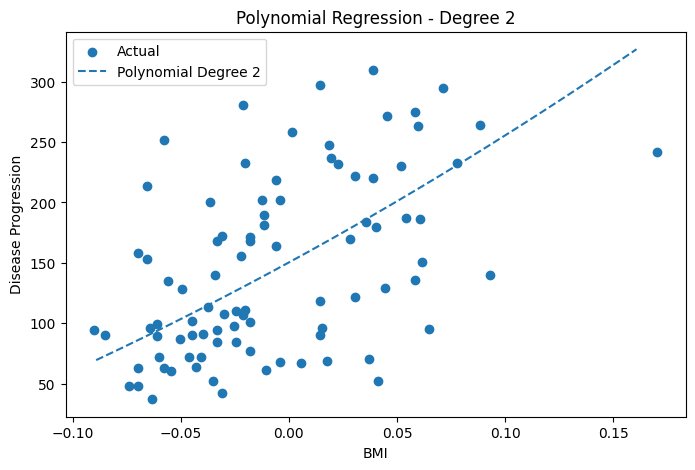

In [29]:
# Generate smooth BMI values
bmi_range = np.linspace(
    X_train_bmi["bmi"].min(),
    X_train_bmi["bmi"].max(),
    200
).reshape(-1, 1)

bmi_range_poly2 = poly2.transform(bmi_range)

predicted_curve2 = poly2_model.predict(
    bmi_range_poly2
)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_bmi["bmi"],
    y_test_bmi,
    label="Actual"
)

plt.plot(
    bmi_range,
    predicted_curve2,
    linestyle="--",
    label="Polynomial Degree 2"
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Polynomial Regression - Degree 2")
plt.legend()

plt.show()

**Degree 3**

In [30]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train_bmi)
X_test_poly3 = poly3.transform(X_test_bmi)

poly3_model = LinearRegression()

poly3_model.fit(
    X_train_poly3,
    y_train_bmi
)

y_pred_poly3 = poly3_model.predict(
    X_test_poly3
)

In [31]:
mse_poly3 = mean_squared_error(
    y_test_bmi,
    y_pred_poly3
)

rmse_poly3 = np.sqrt(mse_poly3)

mae_poly3 = mean_absolute_error(
    y_test_bmi,
    y_pred_poly3
)

r2_poly3 = r2_score(
    y_test_bmi,
    y_pred_poly3
)

print("Polynomial Regression (Degree 3)")
print("--------------------------------")
print("MSE  :", mse_poly3)
print("RMSE :", rmse_poly3)
print("MAE  :", mae_poly3)
print("R²   :", r2_poly3)

Polynomial Regression (Degree 3)
--------------------------------
MSE  : 4064.4433837164365
RMSE : 63.75298725327651
MAE  : 52.18140033344566
R²   : 0.23285636640090268


**Compare Linear, Polynomial 2 and Polynomial 3**

In [32]:
polynomial_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Polynomial Regression Degree 2",
        "Polynomial Regression Degree 3"
    ],
    "MSE": [
        mse_simple,
        mse_poly2,
        mse_poly3
    ],
    "RMSE": [
        rmse_simple,
        rmse_poly2,
        rmse_poly3
    ],
    "MAE": [
        mae_simple,
        mae_poly2,
        mae_poly3
    ],
    "R2": [
        r2_simple,
        r2_poly2,
        r2_poly3
    ]
})

polynomial_comparison

,Model,MSE,RMSE,MAE,R2
0,Simple Linear Regression,4061.825928,63.732456,52.259976,0.233350
1,Polynomial Regression Degree 2,4085.025481,63.914204,52.383912,0.228972
2,Polynomial Regression Degree 3,4064.443384,63.752987,52.181400,0.232856


**Plot the three models together**

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


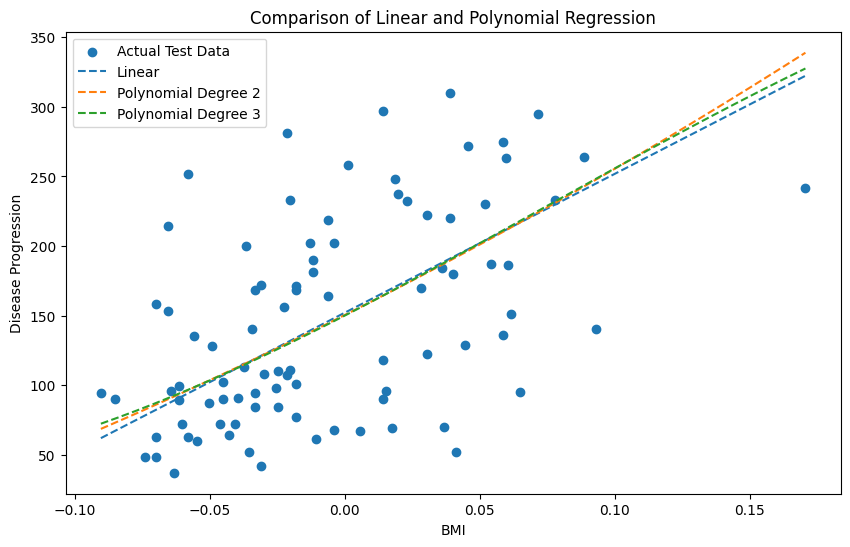

In [33]:
bmi_range = np.linspace(
    X_bmi["bmi"].min(),
    X_bmi["bmi"].max(),
    200
).reshape(-1, 1)

# Linear
linear_pred_curve = simple_lr.predict(bmi_range)

# Polynomial degree 2
poly2_pred_curve = poly2_model.predict(
    poly2.transform(bmi_range)
)

# Polynomial degree 3
poly3_pred_curve = poly3_model.predict(
    poly3.transform(bmi_range)
)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_test_bmi["bmi"],
    y_test_bmi,
    label="Actual Test Data"
)

plt.plot(
    bmi_range,
    linear_pred_curve,
    linestyle="--",
    label="Linear"
)

plt.plot(
    bmi_range,
    poly2_pred_curve,
    linestyle="--",
    label="Polynomial Degree 2"
)

plt.plot(
    bmi_range,
    poly3_pred_curve,
    linestyle="--",
    label="Polynomial Degree 3"
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Comparison of Linear and Polynomial Regression")
plt.legend()

plt.show()

**Check for overfitting**

In [34]:
# Training predictions
y_train_poly2 = poly2_model.predict(X_train_poly2)
y_train_poly3 = poly3_model.predict(X_train_poly3)

# Training R²
train_r2_poly2 = r2_score(y_train_bmi, y_train_poly2)
train_r2_poly3 = r2_score(y_train_bmi, y_train_poly3)

# Test R²
test_r2_poly2 = r2_score(y_test_bmi, y_pred_poly2)
test_r2_poly3 = r2_score(y_test_bmi, y_pred_poly3)

print("Degree 2")
print("Training R²:", train_r2_poly2)
print("Testing R² :", test_r2_poly2)

print("\nDegree 3")
print("Training R²:", train_r2_poly3)
print("Testing R² :", test_r2_poly3)

Degree 2
Training R²: 0.36651069841284856
Testing R² : 0.2289715971205668

Degree 3
Training R²: 0.36665649129084277
Testing R² : 0.23285636640090268


**Gradient Descent for Linear Regression**

**Prepare features for Gradient Descent**

In [35]:
from sklearn.preprocessing import StandardScaler

scaler_gd = StandardScaler()

X_train_gd = scaler_gd.fit_transform(X_train)
X_test_gd = scaler_gd.transform(X_test)

print("Training data shape:", X_train_gd.shape)
print("Testing data shape :", X_test_gd.shape)

Training data shape: (353, 10)
Testing data shape : (89, 10)


**Implement Gradient Descent from scratch**

In [36]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0.0
        self.cost_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):

            # Forward pass
            y_pred = np.dot(X, self.weights) + self.bias

            # Error
            error = y_pred - y

            # Calculate gradients
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate cost
            cost = np.mean(error ** 2) / 2

            self.cost_history.append(cost)

        return self

    def predict(self, X):

        return np.dot(X, self.weights) + self.bias

**Train the Gradient Descent model**

In [37]:
gd_model = LinearRegressionGD(
    learning_rate=0.01,
    epochs=1000
)

gd_model.fit(X_train_gd, y_train)

y_pred_gd = gd_model.predict(X_test_gd)

print("Gradient Descent training completed.")

Gradient Descent training completed.


**Check the learned parameters**

In [38]:
print("Weights:")
print(gd_model.weights)

print("\nBias:")
print(gd_model.bias)

print("\nFinal Cost:")
print(gd_model.cost_history[-1])

Weights:
[  1.94483978 -11.42269492  26.31775084  16.57571791  -6.52876639
  -4.81161938  -9.29112174   7.52396684  20.70061248   2.66702455]

Bias:
153.72990691097522

Final Cost:
1447.3724490881264


**Evaluate Gradient Descent**

In [39]:
mse_gd = mean_squared_error(
    y_test,
    y_pred_gd
)

rmse_gd = np.sqrt(mse_gd)

mae_gd = mean_absolute_error(
    y_test,
    y_pred_gd
)

r2_gd = r2_score(
    y_test,
    y_pred_gd
)

print("Gradient Descent Linear Regression")
print("----------------------------------")
print("MSE  :", mse_gd)
print("RMSE :", rmse_gd)
print("MAE  :", mae_gd)
print("R²   :", r2_gd)

Gradient Descent Linear Regression
----------------------------------
MSE  : 2884.922802987494
RMSE : 53.71147738600656
MAE  : 42.90144239151853
R²   : 0.4554850559357372


**Analyze Gradient Descent convergence**

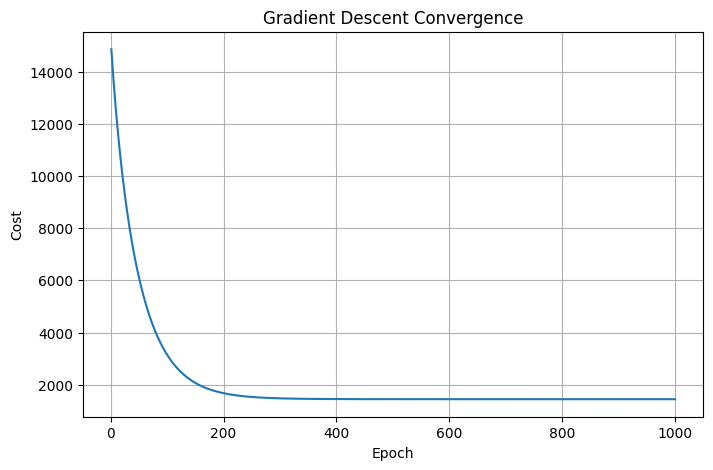

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, gd_model.epochs + 1),
    gd_model.cost_history
)

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.grid(True)

plt.show()

**Compare Gradient Descent with Multiple Linear Regression**

In [41]:
gd_comparison = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Gradient Descent Linear Regression"
    ],
    "MSE": [
        mse_multiple,
        mse_gd
    ],
    "RMSE": [
        rmse_multiple,
        rmse_gd
    ],
    "MAE": [
        mae_multiple,
        mae_gd
    ],
    "R2": [
        r2_multiple,
        r2_gd
    ]
})

gd_comparison

,Model,MSE,RMSE,MAE,R2
0,Multiple Linear Regression,2900.193628,53.853446,42.794095,0.452603
1,Gradient Descent Linear Regression,2884.922803,53.711477,42.901442,0.455485


**Rate Experiment**

In [42]:
learning_rates = [0.001, 0.01, 0.05, 0.1]

gd_lr_results = []

for lr in learning_rates:

    model = LinearRegressionGD(
        learning_rate=lr,
        epochs=1000
    )

    model.fit(X_train_gd, y_train)

    predictions = model.predict(X_test_gd)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    gd_lr_results.append({
        "Learning Rate": lr,
        "Final Cost": model.cost_history[-1],
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

learning_rate_results = pd.DataFrame(gd_lr_results)

learning_rate_results

,Learning Rate,Final Cost,MSE,RMSE,MAE,R2
0,0.001,3130.603270,6331.233887,79.569051,65.218821,-0.194989
1,0.010,1447.372449,2884.922803,53.711477,42.901442,0.455485
2,0.050,1440.530752,2886.983544,53.730657,42.848081,0.455096
3,0.100,1436.760568,2889.924284,53.758016,42.828244,0.454541


**Plot learning-rate convergence**

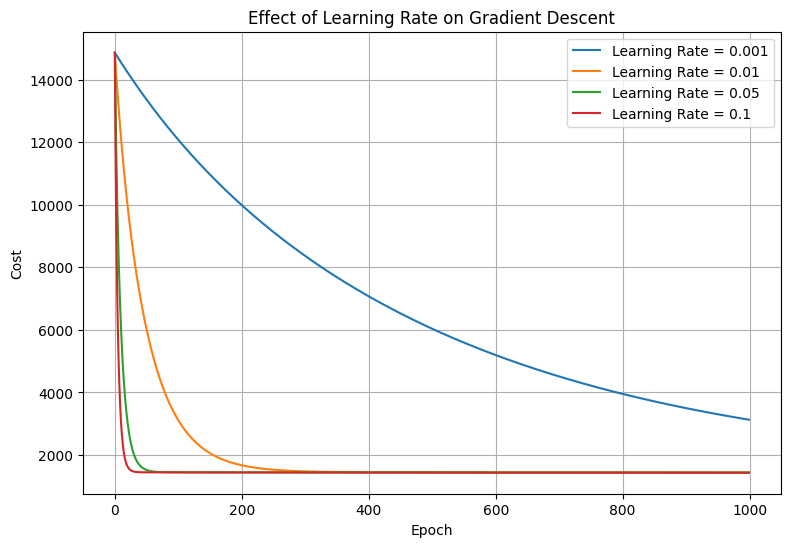

In [43]:
learning_rates = [0.001, 0.01, 0.05, 0.1]

plt.figure(figsize=(9, 6))

for lr in learning_rates:

    model = LinearRegressionGD(
        learning_rate=lr,
        epochs=1000
    )

    model.fit(X_train_gd, y_train)

    plt.plot(
        model.cost_history,
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Effect of Learning Rate on Gradient Descent")
plt.legend()
plt.grid(True)

plt.show()

**Add Gradient Descent to your overall results**

In [44]:
final_results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression (Degree 2)",
        "Polynomial Regression (Degree 3)",
        "Gradient Descent Linear Regression"
    ],
    "MSE": [
        mse_simple,
        mse_multiple,
        mse_poly2,
        mse_poly3,
        mse_gd
    ],
    "RMSE": [
        rmse_simple,
        rmse_multiple,
        rmse_poly2,
        rmse_poly3,
        rmse_gd
    ],
    "MAE": [
        mae_simple,
        mae_multiple,
        mae_poly2,
        mae_poly3,
        mae_gd
    ],
    "R2": [
        r2_simple,
        r2_multiple,
        r2_poly2,
        r2_poly3,
        r2_gd
    ]
})

final_results

,Model,MSE,RMSE,MAE,R2
0,Simple Linear Regression,4061.825928,63.732456,52.259976,0.233350
1,Multiple Linear Regression,2900.193628,53.853446,42.794095,0.452603
2,Polynomial Regression (Degree 2),4085.025481,63.914204,52.383912,0.228972
3,Polynomial Regression (Degree 3),4064.443384,63.752987,52.181400,0.232856
4,Gradient Descent Linear Regression,2884.922803,53.711477,42.901442,0.455485
